<a href="https://colab.research.google.com/github/beingAnujChaudhary/DSFS-Joel-Grus/blob/main/notebooks/chapter_05_statistics/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/DSFS-Joel-Grus.git

# Move into repository
%cd /content/DSFS-Joel-Grus

# Move into Chapter 1 folder
%cd notebooks/chapter_05_statistics

Mounted at /content/drive
Cloning into 'DSFS-Joel-Grus'...
remote: Enumerating objects: 217, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 217 (delta 136), reused 97 (delta 66), pack-reused 0 (from 0)
Receiving objects: 100% (217/217), 1.88 MiB | 12.50 MiB/s, done.
Resolving deltas: 100% (136/136), done.
/content/DSFS-Joel-Grus
/content/DSFS-Joel-Grus/notebooks/chapter_05_statistics


---

# Chapter 5: Statistics — Experiments

## Purpose

This notebook is your playground for exploring statistical concepts beyond the book's examples.

The goal is to:
- Build intuition for how outliers affect central tendency and correlation
- Observe how sample size influences statistical stability
- Explore correlation pitfalls: non-linearity, spurious relationships
- Simulate Simpson's Paradox to understand confounding variables
- Understand why we learn from scratch but deploy with libraries
- Connect statistics to machine learning applications

**Rule:**
> Focus on interpretation, not memorisation. Do not worry about breaking things — experimentation is the point.

---



In [15]:
## Environment Setup

import math
import numpy as np
import pandas as pd
from collections import Counter
import random
import matplotlib.pyplot as plt

# From-scratch statistical functions
def mean(x):
    return sum(x) / len(x)

def median(v):
    n = len(v)
    sorted_v = sorted(v)
    midpoint = n // 2
    if n % 2 == 1:
        return sorted_v[midpoint]
    else:
        return (sorted_v[midpoint-1] + sorted_v[midpoint]) / 2

def de_mean(x):
    x_bar = mean(x)
    return [x_i - x_bar for x_i in x]

def variance(x):
    n = len(x)
    deviations = de_mean(x)
    return sum(d ** 2 for d in deviations) / (n - 1)

def standard_deviation(x):
    return math.sqrt(variance(x))

def quantile(x, p):
    p_index = int(p * len(x))
    return sorted(x)[p_index]

def interquartile_range(x):
    return quantile(x, 0.75) - quantile(x, 0.25)

print("✅ Statistics experiment environment ready!")

✅ Statistics experiment environment ready!


In [6]:
# Base dataset for quick experiments
data = [10, 20, 30, 40, 50]
print(f"Base data: {data}")

Base data: [10, 20, 30, 40, 50]


---

## Experiment 1 — Mean and Outliers

What happens when an extreme value is added?


In [7]:
# Without outlier
data_normal = [10, 20, 30, 40, 50]
print(f"Data without outlier: {data_normal}")
print(f"Mean: {mean(data_normal)}")

# With outlier
data_with_outlier = [10, 20, 30, 40, 50, 1000]
print(f"\nData with outlier: {data_with_outlier}")
print(f"Mean: {mean(data_with_outlier)}")

# Compare
print(f"\nMean changed from {mean(data_normal)} → {mean(data_with_outlier)}")
print(f"That's a {((mean(data_with_outlier) - mean(data_normal)) / mean(data_normal) * 100):.0f}% increase!")


Data without outlier: [10, 20, 30, 40, 50]
Mean: 30.0

Data with outlier: [10, 20, 30, 40, 50, 1000]
Mean: 191.66666666666666

Mean changed from 30.0 → 191.66666666666666
That's a 539% increase!


### 💡 Reflection
- Why did the mean change so dramatically?
- If this were salary data, would the mean represent a "typical" salary?
- When might a single outlier indicate a data error vs. a legitimate extreme value?

---

## Experiment 2 — Median Robustness

Why is the median more resistant to outliers?


In [8]:
data_normal = [10, 20, 30, 40, 50]
data_with_outlier = [10, 20, 30, 40, 50, 1000]

print("Median comparison:")
print(f"  Without outlier: {median(data_normal)}")
print(f"  With outlier:    {median(data_with_outlier)}")
print(f"  → Median barely changed!")

# Compare with mean
print(f"\nMean comparison:")
print(f"  Without outlier: {mean(data_normal)}")
print(f"  With outlier:    {mean(data_with_outlier)}")
print(f"  → Mean changed dramatically!")


Median comparison:
  Without outlier: 30
  With outlier:    35.0
  → Median barely changed!

Mean comparison:
  Without outlier: 30.0
  With outlier:    191.66666666666666
  → Mean changed dramatically!


### 💡 Reflection
- Why is the median less sensitive to outliers?
- When would you report the median instead of the mean? (Hint: income, house prices, response times)

---

## Experiment 3 — Same Mean, Different Spread

Two datasets can have identical means but completely different behavior.


Dataset 1: [48, 49, 50, 51, 52]
Dataset 2: [10, 20, 50, 80, 90]

Mean of dataset 1: 50.0
Mean of dataset 2: 50.0
  → Means are identical!

Standard deviation:
  Dataset 1: 1.58
  Dataset 2: 35.36
  → Dataset 2 is much more spread out


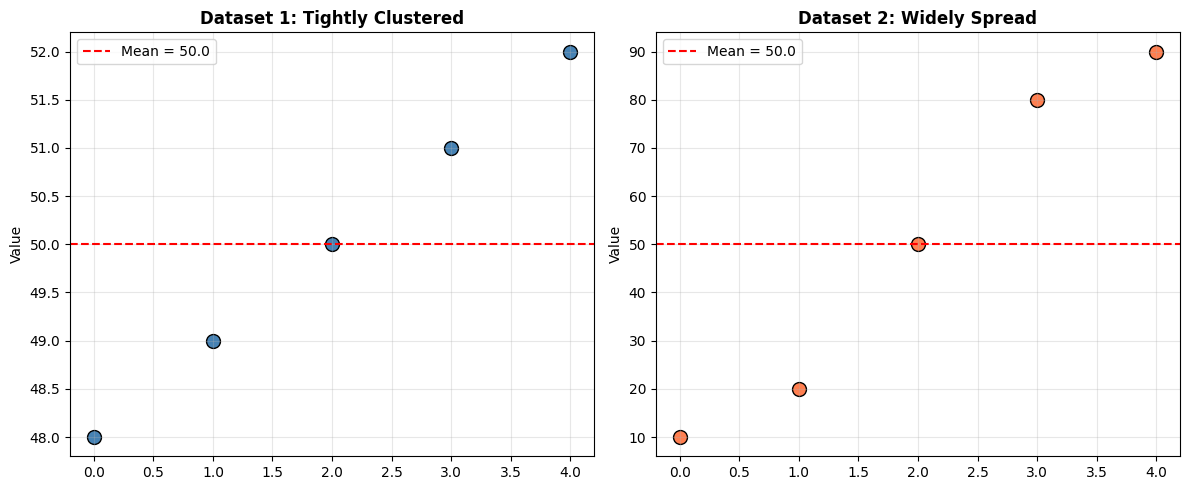

In [9]:
data_1 = [48, 49, 50, 51, 52]     # Tightly clustered
data_2 = [10, 20, 50, 80, 90]     # Widely spread

print(f"Dataset 1: {data_1}")
print(f"Dataset 2: {data_2}")
print(f"\nMean of dataset 1: {mean(data_1)}")
print(f"Mean of dataset 2: {mean(data_2)}")
print(f"  → Means are identical!")

# But look at spread
print(f"\nStandard deviation:")
print(f"  Dataset 1: {standard_deviation(data_1):.2f}")
print(f"  Dataset 2: {standard_deviation(data_2):.2f}")
print(f"  → Dataset 2 is much more spread out")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(len(data_1)), data_1, s=100, color='steelblue', edgecolors='black')
plt.axhline(y=mean(data_1), color='red', linestyle='--', label=f'Mean = {mean(data_1)}')
plt.title("Dataset 1: Tightly Clustered", fontweight='bold')
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(data_2)), data_2, s=100, color='coral', edgecolors='black')
plt.axhline(y=mean(data_2), color='red', linestyle='--', label=f'Mean = {mean(data_2)}')
plt.title("Dataset 2: Widely Spread", fontweight='bold')
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Reflection
- If these were model predictions, which model would you trust more?
- Why is reporting only the mean potentially misleading?

---

## Experiment 4 — Outlier Sensitivity: Mean vs Median vs Std Dev

How do different statistics respond as we add more outliers?


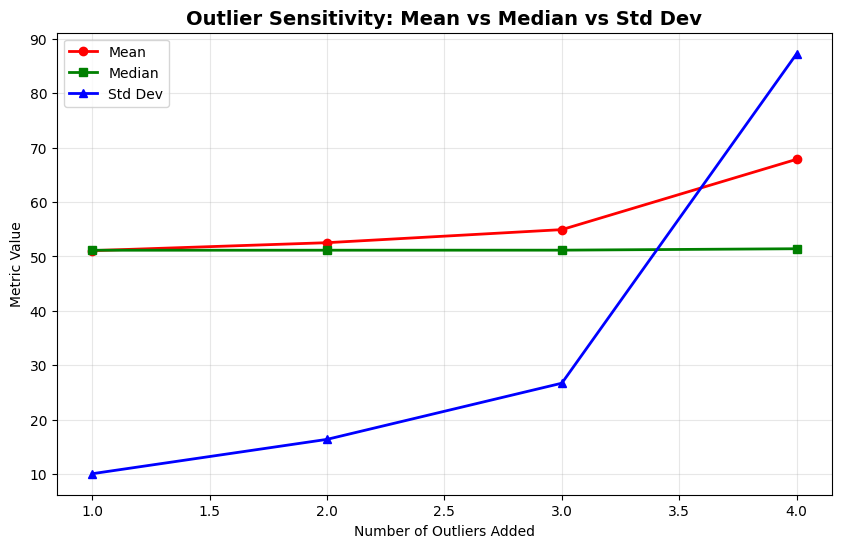

Baseline (no outliers): mean=50.58, median=51.12, std=8.82
1 outlier(s): mean=51.07, median=51.14, std=10.06
2 outlier(s): mean=52.53, median=51.15, std=16.37
3 outlier(s): mean=54.93, median=51.16, std=26.70
4 outlier(s): mean=67.87, median=51.42, std=87.27

🔍 Insight: The median barely moves, but the mean and std dev are pulled dramatically toward the outliers.


In [10]:
# Generate baseline data: roughly normal distribution
random.seed(42)
baseline = [random.gauss(50, 10) for _ in range(100)]

# Add outliers one by one and track metric changes
outliers = [100, 150, 200, 500]
results = []

for i, outlier in enumerate(outliers):
    data = baseline + [outlier] * (i + 1)
    results.append({
        'n_outliers': i + 1,
        'mean': mean(data),
        'median': median(data),
        'std': standard_deviation(data)
    })

# Plot results
plt.figure(figsize=(10, 6))
n_outliers = [r['n_outliers'] for r in results]
means = [r['mean'] for r in results]
medians = [r['median'] for r in results]
stds = [r['std'] for r in results]

plt.plot(n_outliers, means, 'r-o', label='Mean', linewidth=2)
plt.plot(n_outliers, medians, 'g-s', label='Median', linewidth=2)
plt.plot(n_outliers, stds, 'b-^', label='Std Dev', linewidth=2)

plt.xlabel('Number of Outliers Added')
plt.ylabel('Metric Value')
plt.title('Outlier Sensitivity: Mean vs Median vs Std Dev', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Print summary
print(f"Baseline (no outliers): mean={mean(baseline):.2f}, median={median(baseline):.2f}, std={standard_deviation(baseline):.2f}")
for r in results:
    print(f"{r['n_outliers']} outlier(s): mean={r['mean']:.2f}, median={r['median']:.2f}, std={r['std']:.2f}")

print(f"\n🔍 Insight: The median barely moves, but the mean and std dev are pulled dramatically toward the outliers.")


### 💡 Try modifying:
- Change outlier magnitude: `[200, 400, 1000]` instead of `[100, 150, 200, 500]`
- Use skewed baseline data: `[random.expovariate(0.1) for _ in range(100)]`
- **Ask yourself:** When would you prefer median over mean in production ML pipelines?

---

## Experiment 5 — Sample Size & Statistical Stability

How do statistics stabilize as sample size increases?


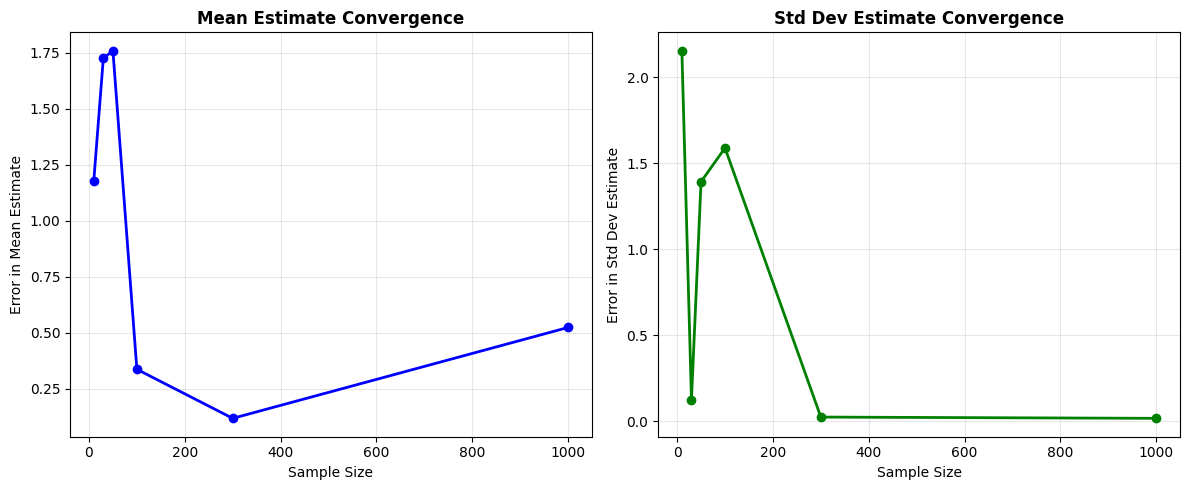

True parameters: mean=50, std=10
n      Mean Error   Std Error   
------------------------------
10     1.1761       2.1530      
30     1.7252       0.1250      
50     1.7589       1.3919      
100    0.3363       1.5881      
300    0.1174       0.0248      
1000   0.5233       0.0174      

🔍 Insight: Larger samples → estimates converge to true values


In [11]:
true_mean = 50
true_std = 10

sample_sizes = [10, 30, 50, 100, 300, 1000]
results = []

for n in sample_sizes:
    sample = [random.gauss(true_mean, true_std) for _ in range(n)]
    results.append({
        'n': n,
        'sample_mean': mean(sample),
        'sample_std': standard_deviation(sample),
        'error_mean': abs(mean(sample) - true_mean),
        'error_std': abs(standard_deviation(sample) - true_std)
    })

# Plot convergence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
ns = [r['n'] for r in results]
errors_mean = [r['error_mean'] for r in results]
plt.plot(ns, errors_mean, 'bo-', linewidth=2)
plt.xlabel('Sample Size')
plt.ylabel('Error in Mean Estimate')
plt.title('Mean Estimate Convergence', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
errors_std = [r['error_std'] for r in results]
plt.plot(ns, errors_std, 'go-', linewidth=2)
plt.xlabel('Sample Size')
plt.ylabel('Error in Std Dev Estimate')
plt.title('Std Dev Estimate Convergence', fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"True parameters: mean={true_mean}, std={true_std}")
print(f"{'n':<6} {'Mean Error':<12} {'Std Error':<12}")
print("-" * 30)
for r in results:
    print(f"{r['n']:<6} {r['error_mean']:<12.4f} {r['error_std']:<12.4f}")

print(f"\n🔍 Insight: Larger samples → estimates converge to true values")


### 💡 Try modifying:
- Change true distribution: uniform, exponential, bimodal
- **Ask yourself:** How large a sample do you need for reliable A/B test results?

---

## Experiment 6 — Variance and Standard Deviation Intuition


In [12]:
data_1 = [48, 49, 50, 51, 52]     # Tight
data_2 = [10, 20, 50, 80, 90]     # Spread

print("Variance comparison:")
print(f"  Dataset 1: {variance(data_1):.2f} (units²)")
print(f"  Dataset 2: {variance(data_2):.2f} (units²)")

print(f"\nStandard deviation comparison:")
print(f"  Dataset 1: {standard_deviation(data_1):.2f} (original units)")
print(f"  Dataset 2: {standard_deviation(data_2):.2f} (original units)")

# Interpretation
std1 = standard_deviation(data_1)
std2 = standard_deviation(data_2)
avg1 = mean(data_1)
avg2 = mean(data_2)

print(f"\nInterpretation:")
print(f"  Dataset 1: Most values within {avg1 - std1:.1f} to {avg1 + std1:.1f}")
print(f"  Dataset 2: Most values within {avg2 - std2:.1f} to {avg2 + std2:.1f}")


Variance comparison:
  Dataset 1: 2.50 (units²)
  Dataset 2: 1250.00 (units²)

Standard deviation comparison:
  Dataset 1: 1.58 (original units)
  Dataset 2: 35.36 (original units)

Interpretation:
  Dataset 1: Most values within 48.4 to 51.6
  Dataset 2: Most values within 14.6 to 85.4


### 💡 Reflection
- Why is standard deviation easier to interpret than variance?
- How would you use standard deviation to detect anomalies? (Hint: z-scores)

---

## Experiment 7 — Quantiles and Percentiles


In [13]:
data = [10, 20, 30, 40, 50, 60, 70, 80, 90]

print("Percentile breakdown:")
print(f"  10th percentile: {quantile(data, 0.10)}")
print(f"  25th percentile (Q1): {quantile(data, 0.25)}")
print(f"  50th percentile (Median): {quantile(data, 0.50)}")
print(f"  75th percentile (Q3): {quantile(data, 0.75)}")
print(f"  90th percentile: {quantile(data, 0.90)}")

# Outlier detection with IQR
scores = [45, 55, 65, 70, 75, 80, 85, 90, 95, 100, 150]  # 150 is outlier
q1 = quantile(scores, 0.25)
q3 = quantile(scores, 0.75)
iqr = interquartile_range(scores)

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = [x for x in scores if x < lower_fence or x > upper_fence]

print(f"\nOutlier detection with IQR:")
print(f"  Data: {scores}")
print(f"  Q1: {q1}, Q3: {q3}, IQR: {iqr}")
print(f"  Fences: [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"  Outliers: {outliers}")


Percentile breakdown:
  10th percentile: 10
  25th percentile (Q1): 30
  50th percentile (Median): 50
  75th percentile (Q3): 70
  90th percentile: 90

Outlier detection with IQR:
  Data: [45, 55, 65, 70, 75, 80, 85, 90, 95, 100, 150]
  Q1: 65, Q3: 95, IQR: 30
  Fences: [20.0, 140.0]
  Outliers: [150]


### 💡 Reflection
- Why might percentiles be more informative than just the mean?
- How is IQR-based outlier detection more robust than standard deviation-based methods?

---

## Experiment 8 — Correlation Intuition

Explore positive, negative, and zero correlation visually.


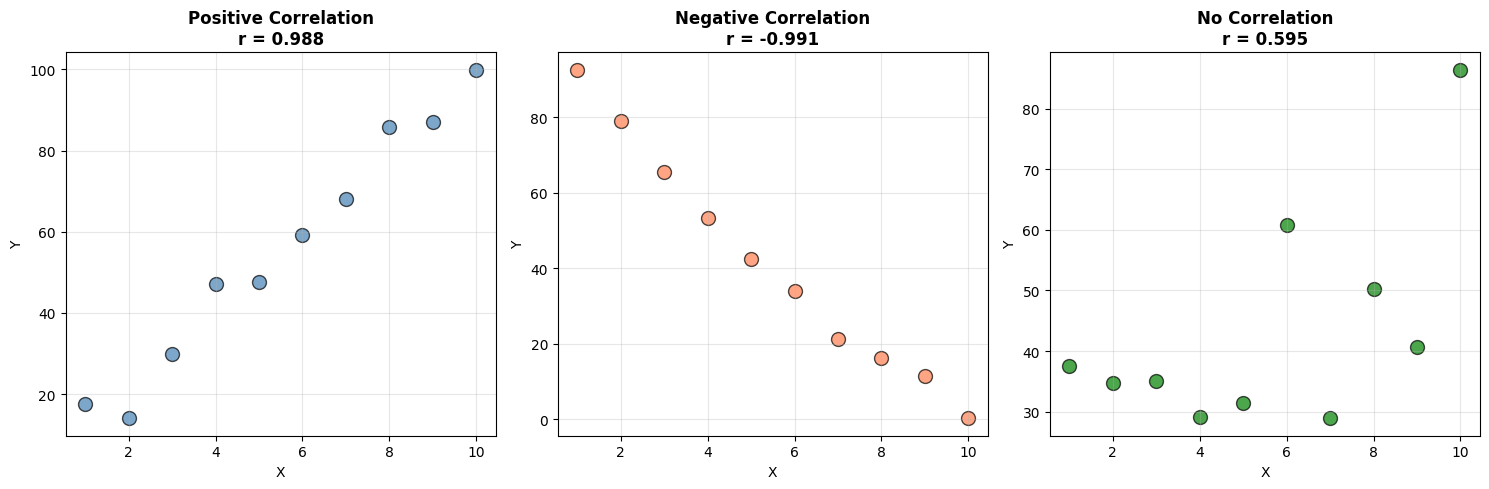

In [16]:
def covariance(x, y):
    n = len(x)
    return sum((x_i - mean(x)) * (y_i - mean(y)) for x_i, y_i in zip(x, y)) / (n - 1)

def correlation(x, y):
    stdev_x = standard_deviation(x)
    stdev_y = standard_deviation(y)
    if stdev_x > 0 and stdev_y > 0:
        return covariance(x, y) / stdev_x / stdev_y
    return 0

# Create three scenarios
np.random.seed(42)

# Positive correlation
x_pos = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y_pos = [xi * 10 + random.gauss(0, 5) for xi in x_pos]

# Negative correlation
x_neg = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y_neg = [100 - xi * 10 + random.gauss(0, 5) for xi in x_neg]

# No correlation
x_none = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
y_none = [random.gauss(50, 15) for _ in range(10)]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(x_pos, y_pos, s=100, alpha=0.7, edgecolors='black', color='steelblue')
plt.title(f"Positive Correlation\nr = {correlation(x_pos, y_pos):.3f}", fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(x_neg, y_neg, s=100, alpha=0.7, edgecolors='black', color='coral')
plt.title(f"Negative Correlation\nr = {correlation(x_neg, y_neg):.3f}", fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(x_none, y_none, s=100, alpha=0.7, edgecolors='black', color='green')
plt.title(f"No Correlation\nr = {correlation(x_none, y_none):.3f}", fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 Reflection
- What type of relationship does each scatter plot show?
- How does the correlation coefficient capture these patterns?

---

## Experiment 9 — Correlation ≠ Causation


In [17]:
print("=" * 60)
print("CORRELATION DOES NOT IMPLY CAUSATION")
print("=" * 60)

examples = [
    ("Ice cream sales ↑, Drowning incidents ↑", "Summer weather (confounding variable)"),
    ("Shoe size ↑, Reading ability ↑", "Age (confounding variable)"),
    ("Number of fire trucks ↑, Fire damage ↑", "Size of fire (confounding variable)"),
    ("TV watching ↑, Obesity ↑", "Sedentary lifestyle, diet (multiple factors)"),
]

for observed, explanation in examples:
    print(f"\n📊 Observed: {observed}")
    print(f"   🔍 Possible explanation: {explanation}")

print(f"\n{'=' * 60}")
print("KEY LESSONS:")
print("  1. Correlation suggests hypotheses worth investigating")
print("  2. Controlled experiments (A/B tests) test causation")
print("  3. Always consider confounding variables")
print("  4. Visualize data before computing correlation")
print(f"{'=' * 60}")


CORRELATION DOES NOT IMPLY CAUSATION

📊 Observed: Ice cream sales ↑, Drowning incidents ↑
   🔍 Possible explanation: Summer weather (confounding variable)

📊 Observed: Shoe size ↑, Reading ability ↑
   🔍 Possible explanation: Age (confounding variable)

📊 Observed: Number of fire trucks ↑, Fire damage ↑
   🔍 Possible explanation: Size of fire (confounding variable)

📊 Observed: TV watching ↑, Obesity ↑
   🔍 Possible explanation: Sedentary lifestyle, diet (multiple factors)

KEY LESSONS:
  1. Correlation suggests hypotheses worth investigating
  2. Controlled experiments (A/B tests) test causation
  3. Always consider confounding variables
  4. Visualize data before computing correlation


### 💡 Reflection
- Can you think of a real example where correlation might be mistaken for causation?
- How would you design an experiment to test whether one variable causes another?

---

## Experiment 10 — Correlation Pitfalls: Non-Linearity & Spurious Relationships


Quadratic relationship (y = x²): correlation = 0.000
  → Perfect relationship, but linear correlation is ZERO!

Spurious correlation (ice cream vs drowning): 0.514


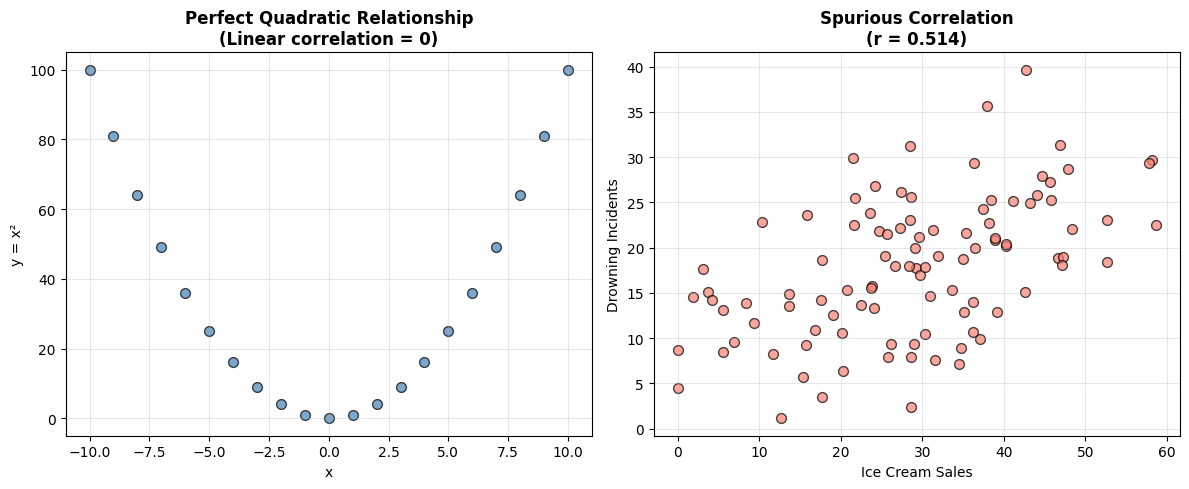


Controlling for age (stratified correlation):
  Age 0-30: r = 0.175 (n=33)
  Age 31-60: r = 0.104 (n=47)
  Age 61-100: r = -0.147 (n=20)

🔍 Insight: The spurious correlation disappears when controlling for age!


In [19]:
# Case 1: Perfect non-linear relationship (zero linear correlation)
x_quad = list(range(-10, 11))
y_quad = [x**2 for x in x_quad]

print(f"Quadratic relationship (y = x²): correlation = {correlation(x_quad, y_quad):.3f}")
print(f"  → Perfect relationship, but linear correlation is ZERO!")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_quad, y_quad, s=50, alpha=0.7, edgecolors='black', color='steelblue')
plt.title("Perfect Quadratic Relationship\n(Linear correlation = 0)", fontweight='bold')
plt.xlabel("x")
plt.ylabel("y = x²")
plt.grid(True, alpha=0.3)

# Case 2: Spurious correlation via confounding variable
random.seed(42)
n = 100
# Confounder: age affects both ice cream sales and drowning incidents
age = [random.randint(5, 80) for _ in range(n)]
ice_cream = [max(0, 50 + random.gauss(0, 10) - 0.5 * a) for a in age]
drowning = [max(0, 30 + random.gauss(0, 5) - 0.3 * a) for a in age]

corr_spurious = correlation(ice_cream, drowning)
print(f"\nSpurious correlation (ice cream vs drowning): {corr_spurious:.3f}")

plt.subplot(1, 2, 2)
plt.scatter(ice_cream, drowning, s=50, alpha=0.7, edgecolors='black', color='salmon')
plt.title(f"Spurious Correlation\n(r = {corr_spurious:.3f})", fontweight='bold')
plt.xlabel("Ice Cream Sales")
plt.ylabel("Drowning Incidents")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Control for confounder: stratify by age groups
age_groups = [(0, 30), (31, 60), (61, 100)]
print("\nControlling for age (stratified correlation):")
for lo, hi in age_groups:
    subset_idx = [i for i, a in enumerate(age) if lo <= a <= hi]
    if len(subset_idx) > 2:
        sub_ice = [ice_cream[i] for i in subset_idx]
        sub_drown = [drowning[i] for i in subset_idx]
        corr_sub = correlation(sub_ice, sub_drown)
        print(f"  Age {lo}-{hi}: r = {corr_sub:.3f} (n={len(subset_idx)})")

print(f"\n🔍 Insight: The spurious correlation disappears when controlling for age!")

### 💡 Try modifying:
- Create a U-shaped relationship: `y = (x-5)²`
- Add a third variable and observe how correlation changes
- **Ask yourself:** How would you detect spurious correlations in real-world data?

---

## Experiment 11 — Simpson's Paradox Simulation

Build and explore a dataset where trends reverse within subgroups.


SIMPSON'S PARADOX: CAMPAIGN COMPARISON

Overall:
  Campaign A: n=100, mean=111.49
  Campaign B: n=100, mean=67.85
  Winner: A ← B appears better!

Within regions:
  Urban:
    Campaign A: n=80, mean=120.36
    Campaign B: n=20, mean=104.99
    Winner: A ← A is better!
  Rural:
    Campaign A: n=20, mean=76.01
    Campaign B: n=80, mean=58.57
    Winner: A ← A is better!

🔍 The Paradox:
  Overall: B > A
  Within each region: A > B
  Cause: Campaign B has more rural users (lower scores)
         Campaign A has more urban users (higher scores)


/tmp/ipykernel_2810/1292817543.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([campaign_a, campaign_b], labels=["Campaign A", "Campaign B"])
/tmp/ipykernel_2810/1292817543.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([urban_a, urban_b, rural_a, rural_b],


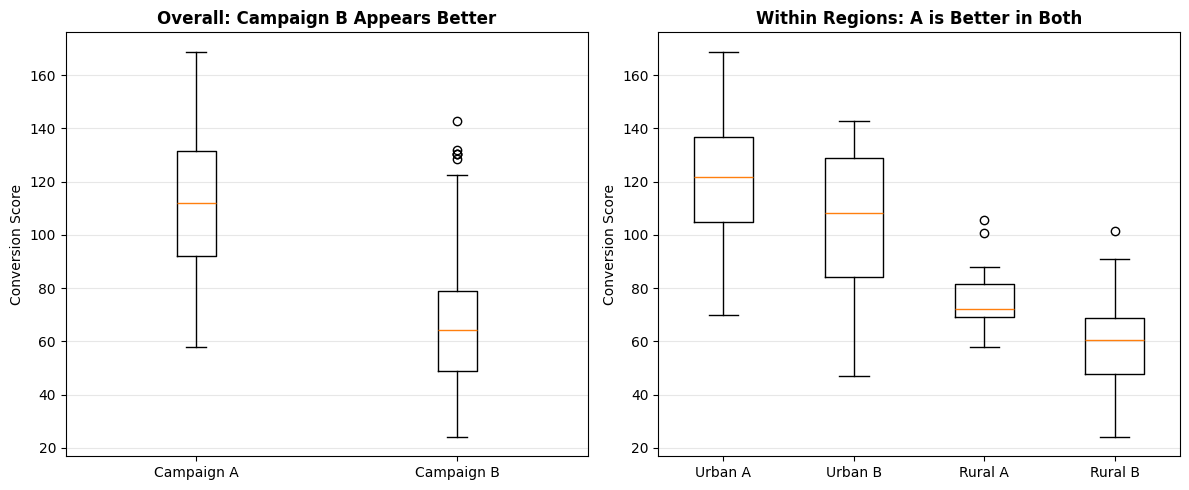

In [20]:
# Scenario: Two marketing campaigns (A vs B) across two regions
# Campaign B looks better overall, but A is better in each region

data = []

# Urban region: Campaign A performs better, but Campaign A has MORE urban users
for _ in range(80):  # Many urban users for Campaign A
    data.append(("Urban", "A", random.gauss(120, 20)))
for _ in range(20):  # Few urban users for Campaign B
    data.append(("Urban", "B", random.gauss(100, 20)))

# Rural region: Campaign A still performs better, but Campaign B has MORE rural users
for _ in range(20):  # Few rural users for Campaign A
    data.append(("Rural", "A", random.gauss(80, 15)))
for _ in range(80):  # Many rural users for Campaign B
    data.append(("Rural", "B", random.gauss(60, 15)))

# Extract values by campaign
campaign_a = [d[2] for d in data if d[1] == "A"]
campaign_b = [d[2] for d in data if d[1] == "B"]

print("=" * 50)
print("SIMPSON'S PARADOX: CAMPAIGN COMPARISON")
print("=" * 50)

print(f"\nOverall:")
print(f"  Campaign A: n={len(campaign_a)}, mean={mean(campaign_a):.2f}")
print(f"  Campaign B: n={len(campaign_b)}, mean={mean(campaign_b):.2f}")
print(f"  Winner: {'B' if mean(campaign_b) > mean(campaign_a) else 'A'} ← B appears better!")

print(f"\nWithin regions:")
for region in ["Urban", "Rural"]:
    a_vals = [d[2] for d in data if d[0] == region and d[1] == "A"]
    b_vals = [d[2] for d in data if d[0] == region and d[1] == "B"]
    print(f"  {region}:")
    print(f"    Campaign A: n={len(a_vals)}, mean={mean(a_vals):.2f}")
    print(f"    Campaign B: n={len(b_vals)}, mean={mean(b_vals):.2f}")
    print(f"    Winner: {'A' if mean(a_vals) > mean(b_vals) else 'B'} ← A is better!")

print(f"\n🔍 The Paradox:")
print(f"  Overall: B > A")
print(f"  Within each region: A > B")
print(f"  Cause: Campaign B has more rural users (lower scores)")
print(f"         Campaign A has more urban users (higher scores)")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot([campaign_a, campaign_b], labels=["Campaign A", "Campaign B"])
plt.title("Overall: Campaign B Appears Better", fontweight='bold')
plt.ylabel("Conversion Score")
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
urban_a = [d[2] for d in data if d[0] == "Urban" and d[1] == "A"]
urban_b = [d[2] for d in data if d[0] == "Urban" and d[1] == "B"]
rural_a = [d[2] for d in data if d[0] == "Rural" and d[1] == "A"]
rural_b = [d[2] for d in data if d[0] == "Rural" and d[1] == "B"]

plt.boxplot([urban_a, urban_b, rural_a, rural_b],
           labels=["Urban A", "Urban B", "Rural A", "Rural B"])
plt.title("Within Regions: A is Better in Both", fontweight='bold')
plt.ylabel("Conversion Score")
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()



### 💡 Try modifying:
- Change the imbalance: make Campaign B have more users in the high-performing region
- Add a third region or third campaign
- **Ask yourself:** How would you design an experiment to avoid this pitfall in A/B testing?

---

## Experiment 12 — Detecting Anomalies


In [21]:
# Normal data with an anomaly
normal_data = [45, 50, 48, 52, 47, 49, 51, 46, 50]
with_anomaly = normal_data + [500]

avg_normal = mean(normal_data)
avg_anomaly = mean(with_anomaly)
std_normal = standard_deviation(normal_data)
std_anomaly = standard_deviation(with_anomaly)

print(f"Normal data: {normal_data}")
print(f"  Mean: {avg_normal:.2f}, Std: {std_normal:.2f}")

print(f"\nWith anomaly: {with_anomaly}")
print(f"  Mean: {avg_anomaly:.2f}, Std: {std_anomaly:.2f}")

# Z-score method for anomaly detection
threshold = 2  # Values more than 2 standard deviations from mean
anomalies = [x for x in with_anomaly if abs(x - avg_normal) > threshold * std_normal]
print(f"\nAnomalies detected (z-score > {threshold}): {anomalies}")

# IQR method for anomaly detection
q1 = quantile(normal_data, 0.25)
q3 = quantile(normal_data, 0.75)
iqr = interquartile_range(normal_data)
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

anomalies_iqr = [x for x in with_anomaly if x < lower_fence or x > upper_fence]
print(f"Anomalies detected (IQR method): {anomalies_iqr}")


Normal data: [45, 50, 48, 52, 47, 49, 51, 46, 50]
  Mean: 48.67, Std: 2.35

With anomaly: [45, 50, 48, 52, 47, 49, 51, 46, 50, 500]
  Mean: 93.80, Std: 142.74

Anomalies detected (z-score > 2): [500]
Anomalies detected (IQR method): [500]


### 💡 Reflection
- Why is anomaly detection important in ML systems?
- What types of anomalies might you encounter in production data?

---

## Experiment 13 — Statistics in ML Thinking


In [22]:
print("=" * 60)
print("STATISTICS IN MACHINE LEARNING")
print("=" * 60)

applications = [
    ("Model Evaluation", "Accuracy, precision, recall, F1-score all rely on statistical aggregation"),
    ("Feature Engineering", "Correlation analysis identifies redundant features; variance detects useless ones"),
    ("Anomaly Detection", "Z-scores and IQR flag unusual data points in production"),
    ("A/B Testing", "Statistical significance tells you if a new model is genuinely better"),
    ("Production Monitoring", "Track mean and variance drift to detect data quality degradation"),
    ("User Behavior Analysis", "Quantiles reveal engagement patterns (e.g., 90th percentile response time)"),
    ("Recommendation Systems", "Similarity metrics rely on statistical measures of closeness"),
]

for app, description in applications:
    print(f"\n📌 {app}")
    print(f"   {description}")

print(f"\n{'=' * 60}")
print("Without statistics, ML systems would be:")
print("  • Unable to evaluate if they're working")
print("  • Blind to data quality issues")
print("  • Incapable of detecting when to retrain")
print("  • Unable to compare model versions objectively")


STATISTICS IN MACHINE LEARNING

📌 Model Evaluation
   Accuracy, precision, recall, F1-score all rely on statistical aggregation

📌 Feature Engineering
   Correlation analysis identifies redundant features; variance detects useless ones

📌 Anomaly Detection
   Z-scores and IQR flag unusual data points in production

📌 A/B Testing
   Statistical significance tells you if a new model is genuinely better

📌 Production Monitoring
   Track mean and variance drift to detect data quality degradation

📌 User Behavior Analysis
   Quantiles reveal engagement patterns (e.g., 90th percentile response time)

📌 Recommendation Systems
   Similarity metrics rely on statistical measures of closeness

Without statistics, ML systems would be:
  • Unable to evaluate if they're working
  • Blind to data quality issues
  • Incapable of detecting when to retrain
  • Unable to compare model versions objectively


---

## Experiment 14 — Reality Check: From-Scratch vs NumPy



In [23]:
import time

# Large dataset for benchmarking
n = 100_000
data = [random.gauss(50, 15) for _ in range(n)]

# From-scratch
start = time.perf_counter()
_ = mean(data)
scratch_mean_time = time.perf_counter() - start

start = time.perf_counter()
_ = standard_deviation(data)
scratch_std_time = time.perf_counter() - start

# NumPy (if available)
try:
    import numpy as np

    data_np = np.array(data)

    start = time.perf_counter()
    _ = np.mean(data_np)
    numpy_mean_time = time.perf_counter() - start

    start = time.perf_counter()
    _ = np.std(data_np, ddof=1)
    numpy_std_time = time.perf_counter() - start

    print(f"Dataset size: {n:,} elements")
    print(f"\n{'Metric':<10} {'From-Scratch':<15} {'NumPy':<15} {'Speedup':<10}")
    print("-" * 50)
    print(f"{'Mean':<10} {scratch_mean_time*1000:>8.2f} ms    {numpy_mean_time*1000:>8.2f} ms    {scratch_mean_time/numpy_mean_time:>6.0f}x")
    print(f"{'Std Dev':<10} {scratch_std_time*1000:>8.2f} ms    {numpy_std_time*1000:>8.2f} ms    {scratch_std_time/numpy_std_time:>6.0f}x")

except ImportError:
    print("⚠️ NumPy not installed. Run: pip install numpy")
    print(f"From-scratch mean time: {scratch_mean_time*1000:.2f} ms for {n:,} elements")
    print(f"From-scratch std time: {scratch_std_time*1000:.2f} ms for {n:,} elements")

print(f"\n💡 When to use what:")
print(f"  From-scratch: Learning, interviews, prototyping, education")
print(f"  NumPy:        Production ML, large datasets, real-time systems")


Dataset size: 100,000 elements

Metric     From-Scratch    NumPy           Speedup   
--------------------------------------------------
Mean           3.25 ms        0.15 ms        21x
Std Dev       20.42 ms        0.36 ms        56x

💡 When to use what:
  From-scratch: Learning, interviews, prototyping, education
  NumPy:        Production ML, large datasets, real-time systems


---

## 🔑 Key Takeaways

| Experiment | Insight | ML/Data Science Connection |
|-----------|---------|----------------------------|
| Mean vs outliers | One extreme value can make the mean meaningless | Use median or trimmed mean for skewed data |
| Median robustness | Median is stable regardless of extreme values | Report median for salary, response time, house price analyses |
| Same mean, different spread | Mean alone hides distribution differences | Always report spread alongside central tendency |
| Outlier sensitivity | Mean and std dev are fragile; median and IQR are robust | Use robust statistics for anomaly detection and feature scaling |
| Sample size | Statistics stabilize with more data | Power analysis for A/B tests; confidence intervals for metrics |
| Correlation pitfalls | Linear correlation misses non-linear patterns | Always visualize before computing correlation |
| Simpson's Paradox | Aggregated data can reverse subgroup trends | Stratify analysis by key variables; avoid biased evaluation |
| Anomaly detection | Z-scores and IQR flag unusual values | Monitor production data for drift and anomalies |
| From-scratch vs libraries | Pure Python is educational; NumPy is production-ready | Learn concepts from scratch; deploy with optimized libraries |

---

## 📝 Final Reflections

### Questions to think about

1. When should I use mean vs median in production systems?
2. Why does variance matter for understanding model behavior?
3. Why are outliers so dangerous for statistical analysis?
4. Why is correlation useful but potentially misleading?
5. How does statistics support ML system monitoring and evaluation?
6. What's the most surprising behavior you observed in these experiments?
7. How would you explain Simpson's Paradox to a non-technical stakeholder?

### Biggest Takeaway

> Statistics is not just mathematics — it's understanding how data behaves.

Strong statistical intuition improves:
- **ML evaluation** — knowing which metrics to trust
- **Experimentation** — designing and interpreting A/B tests
- **Monitoring** — detecting when models degrade in production
- **Feature engineering** — identifying valuable signals vs noise
- **Decision making** — avoiding pitfalls like Simpson's Paradox and spurious correlations

---


**Next Steps:**
1. Pick one experiment and push it further — combine concepts across experiments
2. Create a "statistical checklist" for your future ML projects

> Remember: Statistics isn't about computing numbers — it's about asking better questions and avoiding misleading conclusions.